# notebook for reproducing the Oronto Group stratigraphy presented in Fuentes et al., 2025

## import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from matplotlib.patches import Wedge,Rectangle

from pystrat import pystrat
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family']='arial'
plt.rcParams['font.size']=18
#plt.rc('text', usetex=True)

## read in Oronto Group straitigraphy data

In [2]:
Oronto_litho = pd.read_csv('../data/stratigraphy/Oronto_strat.csv')
# sort by layer number
Oronto_litho = Oronto_litho.sort_values(by='layer')
Oronto_strat = pystrat.Section(Oronto_litho['Thickness'], Oronto_litho['Lithology'], units=Oronto_litho[[ 'Formation']])

 
color_style = pd.read_csv('../data/stratigraphy/Oronto_style.csv') # Strat Column Colors
style=pystrat.Style(labels=color_style['facies'],color_values=color_style[['R','G','B']]/255,width_values=color_style['width'],swatch_values=color_style['swatch'])

Oronto_litho

,layer,Thickness,Lithology,Type,Formation
2,1,750,Conglomerate,FWWB,Copper Harbor
1,2,300,Siltstone,BWB,Nonesuch
0,3,4000,Sandstone,Exposure,Freda


## read in Henry, 1977 pmag data and Slotznick et al., 2023 pmag data with stratigraphic heights
- The stratigraphic heights from both studies are measured from the Nonesuch-Freda contact.
- Therefore negative values represent sites in the Nonesuch Formation, and positive values represent sites in the Freda Formation.

In [3]:
Henry1977_data = pd.read_csv('../data/pmag_compiled/Henry1977/samples.txt', header=1, sep='\t')
Slotznick2023_data = pd.read_csv('../data/pmag_compiled/Slotznick2023/samples.txt', header=1, sep='\t')

Henry1977_data['height'] = Henry1977_data['height'] + Oronto_litho.loc[Oronto_litho['Formation']=='Copper Harbor', 'Thickness'].values[0] + Oronto_litho.loc[Oronto_litho['Formation']=='Nonesuch', 'Thickness'].values[0]

Slotznick2023_data['height'] = Slotznick2023_data['height'] + Oronto_litho.loc[Oronto_litho['Formation']=='Copper Harbor', 'Thickness'].values[0] + Oronto_litho.loc[Oronto_litho['Formation']=='Nonesuch', 'Thickness'].values[0]
Slotznick2023_data

,analysts,azimuth,azimuth_dec_correction,bed_dip,bed_dip_direction,citations,dip,geologic_classes,geologic_types,height,lithologies,method_codes,sample,site
0,NaN,33.6,0.0,81.4,311.5,This study,-29.0,NaN,NaN,1155.90,NaN,SO-CMD-NORTH,PF18-1,PF18-1
1,NaN,83.6,0.0,81.4,311.5,This study,-12.0,NaN,NaN,1155.78,NaN,SO-CMD-NORTH,PF18-2,PF18-2
2,NaN,-13.4,0.0,81.4,311.5,This study,-12.0,NaN,NaN,1155.65,NaN,SO-CMD-NORTH,PF18-3,PF18-3
3,NaN,-22.4,0.0,81.4,311.5,This study,-12.0,NaN,NaN,1155.62,NaN,SO-CMD-NORTH,PF18-4,PF18-4
4,NaN,176.6,0.0,81.4,311.5,This study,-17.0,NaN,NaN,1155.40,NaN,SO-CMD-NORTH,PF18-5,PF18-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,NaN,37.6,0.0,83.0,312.8,This study,-27.0,NaN,NaN,1206.65,NaN,SO-CMD-NORTH,PF18-159,PF18-159
159,NaN,30.6,0.0,83.0,312.8,This study,-17.0,NaN,NaN,1207.40,NaN,SO-CMD-NORTH,PF18-160,PF18-160
160,NaN,42.6,0.0,83.0,312.8,This study,-20.0,NaN,NaN,1207.82,NaN,SO-CMD-NORTH,PF18-161,PF18-161
161,NaN,56.6,0.0,83.0,312.8,This study,-21.0,NaN,NaN,1208.70,NaN,SO-CMD-NORTH,PF18-162,PF18-162


## read in Oronto Group age model data from the subsidence modeling

In [4]:
age_model=pd.read_csv('../data/age_models_output/Oronto_Group_posterior_ages.csv')
age_model['height'] = age_model['height'] - 950
cols = age_model.columns
# toss the height column
cols = cols.drop('height')

# find the 95% CI and mean for each height row
age_model['mean_age'] = age_model[cols].mean(axis=1)
age_model['q025'] = age_model[cols].quantile(0.025, axis=1)
age_model['q975'] = age_model[cols].quantile(0.975, axis=1)

age_model

,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x995,x996,x997,x998,x999,x1000,x1001,mean_age,q025,q975
0,350.0,1085.211315,1085.201969,1084.634317,1085.770761,1086.776352,1086.864517,1086.537083,1085.132296,1084.468548,...,1085.034256,1084.454332,1084.915404,1085.143594,1085.468036,1084.874976,1086.243075,1085.459416,1084.000809,1086.955893
1,360.0,1083.921639,1085.201969,1084.634317,1085.770761,1086.776352,1086.864517,1086.537083,1085.132296,1084.254474,...,1085.034256,1084.454332,1084.915404,1085.143594,1085.468036,1084.874976,1086.243075,1085.332968,1082.892439,1086.893137
2,370.0,1083.921639,1085.201969,1084.047690,1085.770761,1086.776352,1086.864517,1086.537083,1085.132296,1084.254474,...,1085.034256,1084.454332,1084.915404,1085.143594,1085.468036,1084.874976,1086.243075,1085.245706,1082.419757,1086.840157
3,380.0,1083.921639,1085.201969,1084.047690,1085.770761,1086.776352,1086.864517,1086.537083,1085.132296,1084.254474,...,1085.034256,1084.454332,1084.915404,1085.143594,1085.124691,1084.874976,1086.243075,1085.079414,1080.484749,1086.835037
4,390.0,1083.921639,1085.201969,1084.047690,1085.770761,1086.776352,1086.864517,1086.537083,1085.132296,1084.254474,...,1085.034256,1082.877308,1084.915404,1085.143594,1085.124691,1084.874976,1086.243075,1084.937906,1080.068026,1086.825450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,5010.0,1049.604055,1050.454910,1044.873657,1043.354067,1041.456613,1046.405787,1046.108496,1036.571603,1045.458234,...,1050.099307,1045.983215,1047.031250,1049.298145,1041.990673,1038.767776,1041.110238,1044.906544,1031.760094,1052.530559
467,5020.0,1049.604055,1050.454910,1044.873657,1043.354067,1041.456613,1046.405787,1046.108496,1036.571603,1045.458234,...,1050.099307,1045.983215,1047.031250,1049.298145,1041.990673,1038.767776,1041.110238,1044.833218,1031.760094,1052.507213
468,5030.0,1049.604055,1050.454910,1044.873657,1043.354067,1041.456613,1046.405787,1046.108496,1036.571603,1045.458234,...,1050.099307,1045.983215,1047.031250,1049.298145,1041.990673,1038.767776,1041.110238,1044.794263,1031.760094,1052.485870
469,5040.0,1049.604055,1050.454910,1044.873657,1043.354067,1041.456613,1046.405787,1046.108496,1036.571603,1045.458234,...,1050.099307,1045.983215,1047.031250,1049.298145,1041.990673,1038.767776,1041.110238,1044.760259,1031.760094,1052.484164


In [5]:
# Oronto geochron age compilation for stratigraphy constraints
Oronto_ages=pd.read_csv('../data/stratigraphy/Oronto_ages.csv')
Oronto_ages['height'] = Oronto_ages['height'] - 950

In [6]:
br_height= 2.2*1000
br_unct=0.15*1000    

wrf_height=3.72*1000
wrf_unct=1.1*1000

lr_height=5.8*1000
lr_unct=0.1*1000

wp_height=6*1000
wp_unct=1*1000

section_colors='#7997ad'

In [7]:
from matplotlib.lines import Line2D

def add_left_open_bracket(ax, x_right, y_min, y_max, width, **kwargs):
    """
    Draw a bracket that opens to the left:  ]
    (vertical line on right, horizontal ticks pointing left)
    """
    # vertical line
    ax.add_line(Line2D([x_right, x_right], [y_min, y_max], **kwargs))
    
    # top horizontal
    ax.add_line(Line2D([x_right - width, x_right], [y_max, y_max], **kwargs))
    
    # bottom horizontal
    ax.add_line(Line2D([x_right - width, x_right], [y_min, y_min], **kwargs))

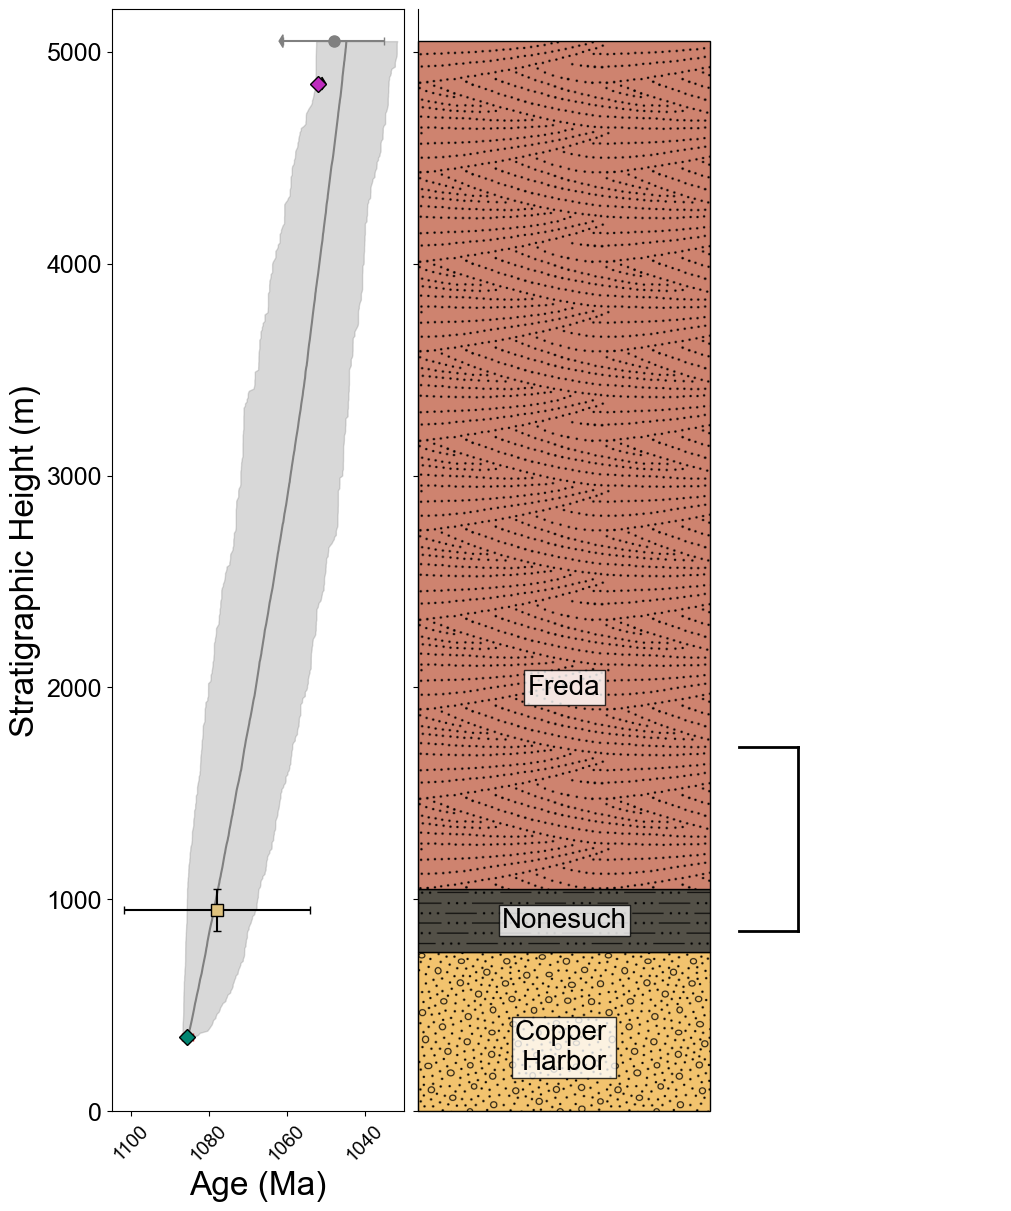

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 12), sharey=True, constrained_layout=True, gridspec_kw={'width_ratios': [1, 2]})

# age model section
ax[0].plot(age_model['mean_age'],age_model['height'], color='grey', linewidth=1.5)

ax[0].fill_betweenx(y=age_model['height'],x1=age_model['q025'],x2=age_model['q975'],alpha=0.3, color='grey')

# ylim to accommodate the section
ax[0].set_ylim([0,5200])
ax[0].set_xlim([1105, 1030])
ax[0].set_xticks([1040, 1060, 1080, 1100])
ax[0].set_xticklabels([1040, 1060, 1080, 1100], fontsize=14, rotation=45)
ax[0].set_xlabel('Age (Ma)', fontsize=24)
ax[0].set_ylabel('Stratigraphic Height (m)', fontsize=24)
Oronto_strat.plot(style,ax[1])

dz_color="#be2bbe"
z_color='#018571'
re_color='#dfc27d'
inv_color='grey'

ax[0].errorbar(1048,6000-950,xerr=13,capsize=3,marker='o',mfc=inv_color,mec=inv_color, ecolor=inv_color, markersize=8,label='Montreal River Monocline Inversion \n (Cannon et al., 1993; U-Pb Calcite \nHodgin et al., 2024)')

ax[0].arrow(x=1048,y=6000-950,dx=13,dy=0,head_length=1,head_width=60,length_includes_head=False,color=inv_color)

ax[0].errorbar(x=Oronto_ages['age '][2],y=Oronto_ages['height'][2],yerr=Oronto_ages['height_sigma'][2],xerr=Oronto_ages['two_sigma'][2],capsize=3,linestyle='none', marker='D',markersize=8, mfc=dz_color,markeredgecolor='black', label='U/Pb Detrital Zircon \n (Hodgin et al., 2024)')

ax[0].arrow(x=1052,y=5800-950,dx=-1,dy=0,head_length=1,head_width=60,length_includes_head=False,color='black')

ax[0].errorbar(x=Oronto_ages['age '][1],y=Oronto_ages['height'][1],yerr=Oronto_ages['height_sigma'][1],xerr=Oronto_ages['two_sigma'][1],capsize=3, marker='s',markersize=8, mfc=re_color,mec='black',ecolor='black',label='Re-Os \n(Cumming et al., 2013)')

ax[0].errorbar(x=Oronto_ages['age '][0],y=Oronto_ages['height'][0],yerr=Oronto_ages['height_sigma'][0],xerr=Oronto_ages['two_sigma'][0],capsize=3,linestyle='none', marker='D',markersize=8, mfc=z_color,mec='black',label='U/Pb Zircon \n(Fairchild et al., 2017)')


ax[1].tick_params('x', top=False,labeltop=False)
ax[1].spines['bottom'].set_visible(False)
ax[1].tick_params('x', bottom=False,labelbottom=False)
ax[1].set_ylabel(None)
ax[1].grid(False)

ax[1].text(0.25,2*1000,'Freda',fontsize=20,
        bbox=dict(boxstyle="square, pad=0.15",fc='white',alpha=0.8),
        horizontalalignment='center',
        verticalalignment='center')
ax[1].text(0.25,.9*1000,'Nonesuch',fontsize=20,
        bbox=dict(boxstyle="square, pad=0.1",fc='white',alpha=0.8),
        horizontalalignment='center',
        verticalalignment='center')
ax[1].text(0.25,0.3*1000,'Copper \nHarbor',fontsize=20, 
        bbox=dict(boxstyle="square, pad=0.1",fc='white',alpha=0.8),
        horizontalalignment='center',
        verticalalignment='center')

# now add an open square bracket that show the range of stratigraphic heights that the pmag data points are from on the first axis

add_left_open_bracket(
    ax[1],0.65,
    y_min=Henry1977_data['height'].min(),
    y_max=Henry1977_data['height'].max(),
    width=0.1,
    color='black',
    linewidth=2
)

# ax[0].legend(loc=(0.8,0.01),fontsize=12,fancybox=False,framealpha=None,edgecolor='black',title='Chronostratigraphic \nConstraints',title_fontsize=16)



# now add the pmag data points as swarm plot that shares y-axis with the strat column

# ax[1].scatter(np.random.normal(0.75,0.05,size=len(Henry1977_data)), Henry1977_data['height'], color='black', label='Henry, 1977', zorder=10)
# ax[1].scatter(np.random.normal(0.25,0.05,size=len(Slotznick2023_data)), Slotznick2023_data['height'], color='red', label='Slotznick et al., 2023', zorder=10)
# ax[1].legend(loc='upper right')

plt.savefig('../figure/Oronto_strat.pdf',bbox_inches='tight')